# **Detecting Rip Currents on Beaches**
CS4343 Deep Learning Final Project

Team: Sidharth Atluri, Nicholas Calcasola, Vincent Grassi, Logan Winters

## Notebook roadmap
1. Setup and loading the dataset
2. Data exploration
3. Cleaning and the train / validation / test split
4. Model training (four conditions)
5. Test-set evaluation, learning curves and hypothesis checks
6. Error analysis (failure cases)

## 1. Setup: load the RipAID dataset
Mounts Google Drive, copies the dataset zip to the Colab VM and extracts it. **RipAID v2.0.0** (Zenodo, CC-BY 4.0) has 6,789 RGB images with oriented-bounding-box labels in YOLO-OBB format, from three kinds of sources: fixed beach cameras, crowd-sourced smartphone photos and aerial imagery.

In [5]:
# Mount Google Drive and load the dataset

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import zipfile

DRIVE_ZIP = Path(
    "/content/drive/MyDrive/Deep Learning Final/RipAID_v2.0.0_yolo-obb.zip"
)

LOCAL_ZIP = Path("/content/RipAID_v2.0.0_yolo-obb.zip")
DATA_DIR = Path("/content/RipAID")

if not LOCAL_ZIP.exists():
    shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)

if not DATA_DIR.exists():
    DATA_DIR.mkdir()

    with zipfile.ZipFile(LOCAL_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

print("Dataset loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded.


## 2. Data exploration
We check that every image has a label file, look at sample labels, and count boxes per class. Classes are `0 = rip_current`, `1 = sediment`, `2 = doubt` (visually ambiguous). The notebook shows **1,082 images with no annotations**, 4,103 rip_current boxes, 1,437 sediment boxes and 4,591 doubt boxes.

In [6]:
# Get image and label files

RIPAID_DIR = DATA_DIR / "RipAID_v2.0.0_yolo-obb"
IMAGE_DIR = RIPAID_DIR / "images"
LABEL_DIR = RIPAID_DIR / "labels"

image_files = sorted([
    path for path in IMAGE_DIR.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
])

label_files = sorted(LABEL_DIR.glob("*.txt"))

print("Images:", len(image_files))
print("Labels:", len(label_files))

Images: 6789
Labels: 6789


In [ ]:
# Look at a few filenames and labels

print("Sample images:")
for path in image_files[:5]:
    print(path.name)

print("\nSample labels:")
for label_path in label_files[:3]:
    print("\n", label_path.name)

    with open(label_path, "r") as file:
        print(file.read())

Sample images:
1287_jpg.rf.e116aecf057a3a16682b914ef319d6b5.jpg
2018-12-26-12-52-16-1942935114461067684_9857700250_jpg.rf.f5404b8150691173144b845863a17ab8.jpg
2019-02-20-14-48-02-1983611020502765771_9857700250_jpg.rf.d14ec446a0144f24358054f4f97ea920.jpg
2019-02-23-18-52-17-1985908288350315429_9857700250_jpg.rf.5eaa76b6f415c0ec5195311c1b3ec312.jpg
2019-02-28-09-57-11-1989262839530766581_9857700250_jpg.rf.cf80f3fbe23634db9607bc2de081452b.jpg

Sample labels:

 1287_jpg.rf.e116aecf057a3a16682b914ef319d6b5.txt
0 0.532773 0.178947 0.859597 0.194359 0.857227 0.244600 0.530403 0.229188


 2018-12-26-12-52-16-1942935114461067684_9857700250_jpg.rf.f5404b8150691173144b845863a17ab8.txt


 2019-02-20-14-48-02-1983611020502765771_9857700250_jpg.rf.d14ec446a0144f24358054f4f97ea920.txt
0 0.139701 0.309977 0.526183 0.359487 0.512534 0.466038 0.126051 0.416529



In [ ]:
# Check the class distribution

from collections import Counter

class_counts = Counter()
empty_labels = 0

for label_path in label_files:
    with open(label_path, "r") as file:
        lines = [line.strip() for line in file if line.strip()]

    if not lines:
        empty_labels += 1
        continue

    for line in lines:
        class_counts[int(line.split()[0])] += 1

print("Empty labels:", empty_labels)

for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id}: {count}")

Empty labels: 1082
Class 0: 4103
Class 1: 1437
Class 2: 4591


## 3. Cleaning and the train / validation / test split
**Cleaning rule.** We keep (a) images whose boxes are *only* clear `rip_current`, and (b) images with no annotations, used as background (negative) examples. This gives **3,942 images: 2,860 with rips and 1,082 negatives.** Images containing `doubt` or `sediment` boxes are dropped to keep the labels clean.

**Split.** A random, stratified **70 / 15 / 15** split (`random_state=42`, stratified by rip vs. no rip) gives **2,759 train / 591 validation / 592 test** images. The test set (429 rips, 163 negatives) is used only for final evaluation.


In [7]:
# Keep clear rip-current images and negative images

RIP_CURRENT = 0
SEDIMENT = 1
DOUBT = 2

clean_images = []
clean_labels = []
targets = []

for image_path in image_files:
    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    with open(label_path, "r") as file:
        lines = [line.strip() for line in file if line.strip()]

    if not lines:
        clean_images.append(image_path)
        clean_labels.append(label_path)
        targets.append(0)
        continue

    class_ids = {int(line.split()[0]) for line in lines}

    if class_ids == {RIP_CURRENT}:
        clean_images.append(image_path)
        clean_labels.append(label_path)
        targets.append(1)

print("Clean dataset:", len(clean_images))
print("Rip-current images:", sum(targets))
print("Negative images:", targets.count(0))

Clean dataset: 3942
Rip-current images: 2860
Negative images: 1082


In [8]:
# Split into 70% training, 15% validation, and 15% testing

from sklearn.model_selection import train_test_split

indices = list(range(len(clean_images)))

train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=targets
)

temp_targets = [targets[i] for i in temp_indices]

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=42,
    stratify=temp_targets
)

print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))

Train: 2759
Validation: 591
Test: 592


In [9]:
# Create the YOLO dataset folders

OUTPUT_DIR = Path("/content/RipAID_clean")

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for split in ["train", "val", "test"]:
    (OUTPUT_DIR / "images" / split).mkdir(parents=True)
    (OUTPUT_DIR / "labels" / split).mkdir(parents=True)


def copy_split(indices, split):
    for index in indices:
        image_path = clean_images[index]
        label_path = clean_labels[index]

        shutil.copy2(
            image_path,
            OUTPUT_DIR / "images" / split / image_path.name
        )

        shutil.copy2(
            label_path,
            OUTPUT_DIR / "labels" / split / label_path.name
        )


copy_split(train_indices, "train")
copy_split(val_indices, "val")
copy_split(test_indices, "test")

print("Dataset split complete.")

Dataset split complete.


In [10]:
# Create the YOLO dataset config

yaml_content = f"""
path: {OUTPUT_DIR}
train: images/train
val: images/val
test: images/test

names:
  0: rip_current
"""

with open(OUTPUT_DIR / "data.yaml", "w") as file:
    file.write(yaml_content)

print("data.yaml created.")

data.yaml created.


### Labeled training examples
Green outlines are the ground-truth oriented boxes.

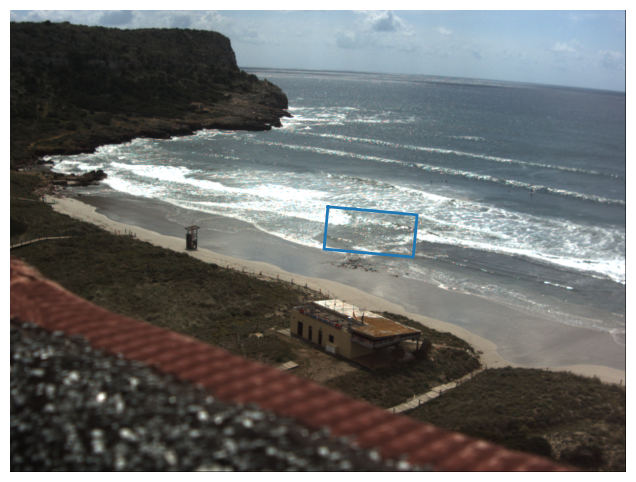

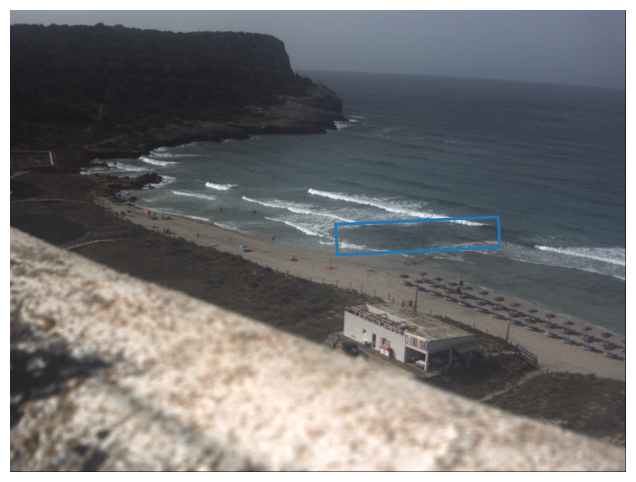

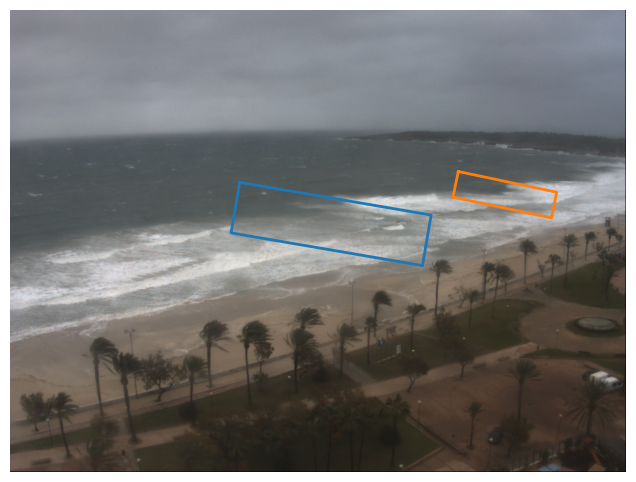

In [ ]:
# Show a few labeled training images

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def show_labeled_image(image_path, label_path):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    plt.figure(figsize=(9, 6))
    plt.imshow(image)

    with open(label_path, "r") as file:
        for line in file:
            if not line.strip():
                continue

            values = list(map(float, line.split()[1:]))

            points = np.array([
                [values[0] * width, values[1] * height],
                [values[2] * width, values[3] * height],
                [values[4] * width, values[5] * height],
                [values[6] * width, values[7] * height]
            ])

            points = np.vstack([points, points[0]])
            plt.plot(points[:, 0], points[:, 1], linewidth=2)

    plt.axis("off")
    plt.show()


positive_indices = [
    i for i in train_indices
    if targets[i] == 1
]

for index in positive_indices[:3]:
    show_labeled_image(
        clean_images[index],
        clean_labels[index]
    )

## 4. Model training
All four runs start from the same pretrained `yolo26n-obb.pt`, with image size 640, batch size 16, 25 epochs and weight decay 0.0005. The checkpoint with the best validation fitness is kept.

| Condition | Optimizer | Augmentation |
|---|---|---|
| Adam, no aug | Adam, lr0 = 0.01 | All HSV, geometric, flip, mosaic and mixup augmentation turned **off** |
| Adam + aug | Adam, lr0 = 0.01 | Ultralytics defaults: HSV jitter, scale, translate, horizontal flip, mosaic |
| SGD, no aug | SGD, lr0 = 0.01, momentum 0.9 | off |
| SGD + aug | SGD, lr0 = 0.01, momentum 0.9 | Ultralytics defaults |

The function `train_model()` below runs one condition. Each run took about 40 minutes on a Colab T4 GPU.

In [11]:
# Set up YOLO training

%pip install -q ultralytics

import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

RESULTS_DIR = Path(
    "/content/drive/MyDrive/Deep Learning Final/results"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 5.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Device: Tesla T4


In [12]:
from pathlib import Path
from ultralytics import YOLO

RESULTS_DIR = Path(
    "/content/drive/MyDrive/Deep Learning Final/results"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def train_model(optimizer="Adam", augmented=False, epochs=25):

    aug_name = "aug" if augmented else "noaug"

    run_name = (
        f"ripcurrent_yolo26nobb_"
        f"{optimizer.lower()}_{aug_name}_{epochs}ep"
    )

    print("Run:", run_name)

    # Start every experiment from the same pretrained model.
    model = YOLO("yolo26n-obb.pt")

    # Optimizer-specific settings
    optimizer_args = {}

    if optimizer.lower() == "sgd":
        optimizer_args["momentum"] = 0.9

    # Augmentation settings
    augmentation_args = {}

    if not augmented:
        augmentation_args = {
            "hsv_h": 0.0,
            "hsv_s": 0.0,
            "hsv_v": 0.0,
            "degrees": 0.0,
            "translate": 0.0,
            "scale": 0.0,
            "shear": 0.0,
            "perspective": 0.0,
            "flipud": 0.0,
            "fliplr": 0.0,
            "mosaic": 0.0,
            "mixup": 0.0,
            "copy_paste": 0.0
        }

    results = model.train(
        data=str(OUTPUT_DIR / "data.yaml"),
        epochs=epochs,
        imgsz=640,
        batch=16,
        device=DEVICE,

        optimizer=optimizer,

        save=True,
        save_period=5,

        project=str(RESULTS_DIR),
        name=run_name,
        exist_ok=False,

        **optimizer_args,
        **augmentation_args
    )

    return model, results

In [ ]:
# Adam - No Augmentation
adam_noaug_model, adam_noaug_results = train_model(
    optimizer="Adam",
    augmented=False,
    epochs=25
)

Run: ripcurrent_yolo26nobb_adam_noaug_25ep
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RipAID_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-obb.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=ripcurrent_y

In [ ]:
# Adam - Augmentation
adam_aug_model, adam_aug_results = train_model(
    optimizer="Adam",
    augmented=True,
    epochs=25
)

Run: ripcurrent_yolo26nobb_adam_aug_25ep
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RipAID_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ripcurrent_y

In [ ]:
sgd_noaug_model, sgd_noaug_results = train_model(
    optimizer="SGD",
    augmented=False,
    epochs=25
)

Run: ripcurrent_yolo26nobb_sgd_noaug_25ep
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RipAID_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-obb.pt, momentum=0.9, mosaic=0.0, multi_scale=0.0, name=ripcurrent_yolo

In [13]:
sgd_aug_model, sgd_aug_results = train_model(
    optimizer="SGD",
    augmented=True,
    epochs=25
)

Run: ripcurrent_yolo26nobb_sgd_aug_25ep
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RipAID_clean/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-obb.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, name=ripcurrent_yolo

## 5. Evaluation
The next cells reload Drive, rebuild the identical split (the assertion checks it matches the 2,759 / 591 / 592 sizes) and locate the four trained runs. Each model's `best.pt` is then scored on both the validation and the held-out **test** set. A detection is a true positive when oriented-box IoU > 0.5.

In [14]:
from google.colab import drive
drive.mount("/content/drive")
%pip install -q ultralytics

from pathlib import Path
import shutil, zipfile, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from ultralytics import YOLO

assert torch.cuda.is_available(), "No GPU: Runtime > Change runtime type > T4 GPU"
DEVICE = 0

DRIVE_ZIP   = Path("/content/drive/MyDrive/Deep Learning Final/RipAID_v2.0.0_yolo-obb.zip")
RESULTS_DIR = Path("/content/drive/MyDrive/Deep Learning Final/results")
LOCAL_ZIP, DATA_DIR = Path("/content/RipAID_v2.0.0_yolo-obb.zip"), Path("/content/RipAID")

if not LOCAL_ZIP.exists(): shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)
if not DATA_DIR.exists():
    DATA_DIR.mkdir()
    with zipfile.ZipFile(LOCAL_ZIP) as z: z.extractall(DATA_DIR)
print("Ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready.


In [15]:
#Rebuilding the exact same split

from sklearn.model_selection import train_test_split

IMAGE_DIR = DATA_DIR / "RipAID_v2.0.0_yolo-obb" / "images"
LABEL_DIR = DATA_DIR / "RipAID_v2.0.0_yolo-obb" / "labels"
image_files = sorted(p for p in IMAGE_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})

# Same cleaning rule as the training notebook: clear rip_current images + empty (negative) images
clean_images, targets = [], []
for p in image_files:
    lines = [l for l in (LABEL_DIR / f"{p.stem}.txt").read_text().splitlines() if l.strip()]
    if not lines:
        clean_images.append(p); targets.append(0); continue
    if {int(l.split()[0]) for l in lines} == {0}:
        clean_images.append(p); targets.append(1)

idx = list(range(len(clean_images)))
train_i, temp_i = train_test_split(idx, test_size=0.30, random_state=42, stratify=targets)
val_i, test_i   = train_test_split(temp_i, test_size=0.50, random_state=42, stratify=[targets[i] for i in temp_i])
print("Train/Val/Test:", len(train_i), len(val_i), len(test_i))
assert (len(train_i), len(val_i), len(test_i)) == (2759, 591, 592), "Split differs from the training notebook!"

OUTPUT_DIR = Path("/content/RipAID_clean")
if OUTPUT_DIR.exists(): shutil.rmtree(OUTPUT_DIR)
def copy_split(indices, split, root=OUTPUT_DIR):
    (root / "images" / split).mkdir(parents=True, exist_ok=True); (root / "labels" / split).mkdir(parents=True, exist_ok=True)
    for i in indices:
        p = clean_images[i]
        shutil.copy2(p, root / "images" / split / p.name)
        shutil.copy2(LABEL_DIR / f"{p.stem}.txt", root / "labels" / split / f"{p.stem}.txt")
for s, ii in [("train", train_i), ("val", val_i), ("test", test_i)]: copy_split(ii, s)
DATA_YAML = OUTPUT_DIR / "data.yaml"
DATA_YAML.write_text(f"path: {OUTPUT_DIR}\ntrain: images/train\nval: images/val\ntest: images/test\n\nnames:\n  0: rip_current\n")
print("Test positives:", sum(targets[i] for i in test_i), "| test negatives:", sum(1 - targets[i] for i in test_i))

Train/Val/Test: 2759 591 592
Test positives: 429 | test negatives: 163


In [16]:
# Locating Four Trained Runs
CONDITIONS = [("adam", "noaug"), ("adam", "aug"), ("sgd", "noaug"), ("sgd", "aug")]
LABELS = {c: f"{c[0].upper() if c[0]=='sgd' else 'Adam'}{' + aug' if c[1]=='aug' else ' (no aug)'}" for c in CONDITIONS}

RUNS = {}
for opt, aug in CONDITIONS:
    cands = [d for d in RESULTS_DIR.glob(f"ripcurrent_yolo26nobb_{opt}_{aug}_25ep*")
             if (d / "weights" / "best.pt").exists() and (d / "results.csv").exists()]
    # Prefer a COMPLETED run (25 epochs); among those, the newest
    cands = [d for d in cands if len(pd.read_csv(d / "results.csv")) == 25]
    assert cands, f"No completed 25-epoch run found for {opt}/{aug} in {RESULTS_DIR}"
    RUNS[(opt, aug)] = max(cands, key=lambda d: d.stat().st_mtime)
    print(f"{LABELS[(opt, aug)]:16s} -> {RUNS[(opt, aug)].name}")

Adam (no aug)    -> ripcurrent_yolo26nobb_adam_noaug_25ep-4
Adam + aug       -> ripcurrent_yolo26nobb_adam_aug_25ep
SGD (no aug)     -> ripcurrent_yolo26nobb_sgd_noaug_25ep
SGD + aug        -> ripcurrent_yolo26nobb_sgd_aug_25ep-2


In [17]:
# Test Set Evaluation
EVAL_DIR = Path("/content/eval"); EVAL_DIR.mkdir(exist_ok=True)

def evaluate(opt, aug, split="test", data=DATA_YAML, tag=""):
    model = YOLO(str(RUNS[(opt, aug)] / "weights" / "best.pt"))
    m = model.val(data=str(data), split=split, imgsz=640, batch=16, device=DEVICE,
                  project=str(EVAL_DIR), name=f"{opt}_{aug}_{split}{tag}", exist_ok=True, plots=True, verbose=False)
    return dict(condition=LABELS[(opt, aug)], optimizer=opt, augmented=(aug == "aug"), split=split,
                precision=m.box.mp, recall=m.box.mr, mAP50=m.box.map50, mAP50_95=m.box.map)

rows = [evaluate(o, a, s) for o, a in CONDITIONS for s in ("val", "test")]
res = pd.DataFrame(rows)
res.to_csv(RESULTS_DIR / "final_val_test_metrics.csv", index=False)

table = res[res.split == "test"].set_index("condition")[["precision", "recall", "mAP50", "mAP50_95"]].round(3)
print("TEST SET RESULTS"); display(table)
print("mAP50 > 0.5 success criterion met:", (table.mAP50 > 0.5).to_dict())

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-obb summary (fused): 129 layers, 2,446,602 parameters, 0 gradients, 5.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2486.7±1340.8 MB/s, size: 1262.3 KB)
val: Scanning /content/RipAID_clean/labels/val... 591 images, 162 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 591/591 497.5it/s 1.2s
val: New cache created: /content/RipAID_clean/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 2.2it/s 17.0s
                   all        591        502      0.821      0.675      0.763      0.379
Speed: 1.8ms preprocess, 5.1ms inference, 0.0ms loss, 4.7ms postprocess per image
Results saved to /content/eval/adam_noaug_val
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-obb summary (fused): 129 layers, 2,446,602 parameters, 0 gradients, 5.6 GFLOPs
val: Fast image access ✅ (ping: 

,precision,recall,mAP50,mAP50_95
condition,,,,
Adam (no aug),0.775,0.715,0.772,0.395
Adam + aug,0.857,0.800,0.850,0.491
SGD (no aug),0.833,0.743,0.825,0.450
SGD + aug,0.863,0.788,0.878,0.520


mAP50 > 0.5 success criterion met: {'Adam (no aug)': True, 'Adam + aug': True, 'SGD (no aug)': True, 'SGD + aug': True}


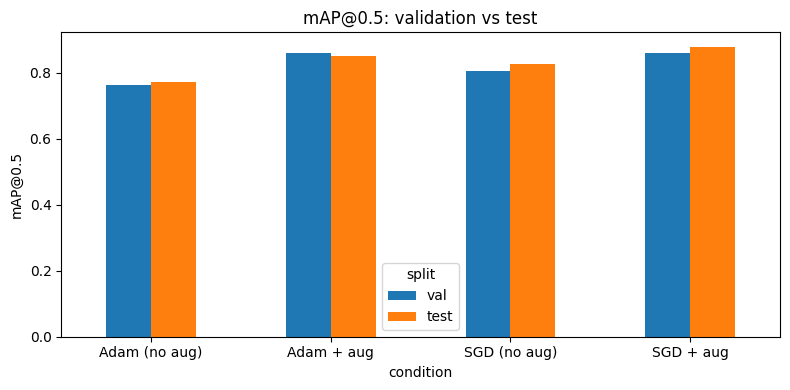

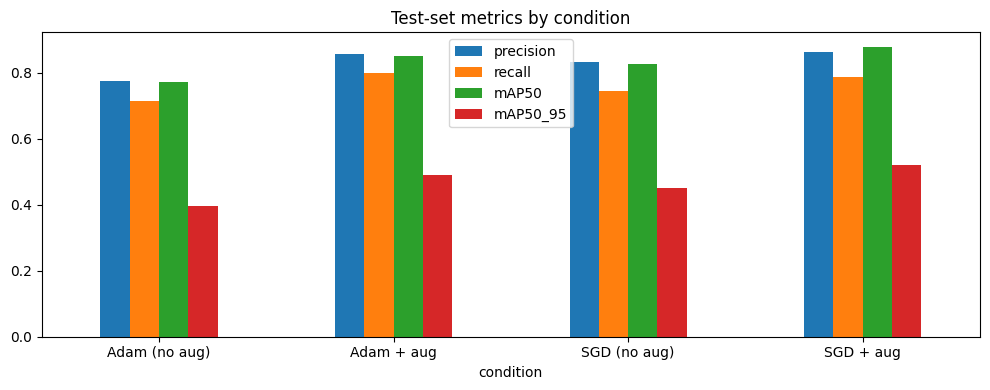

In [18]:
# Validation vs test: large gaps would signal overfitting to the validation set
pivot = res.pivot(index="condition", columns="split", values="mAP50").loc[[LABELS[c] for c in CONDITIONS]]
ax = pivot[["val", "test"]].plot.bar(figsize=(8, 4), rot=0); ax.set_ylabel("mAP@0.5"); ax.set_title("mAP@0.5: validation vs test")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "val_vs_test_map50.png", dpi=150); plt.show()
metric_ax = table.plot.bar(figsize=(10, 4), rot=0); metric_ax.set_title("Test-set metrics by condition")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "test_metrics_by_condition.png", dpi=150); plt.show()

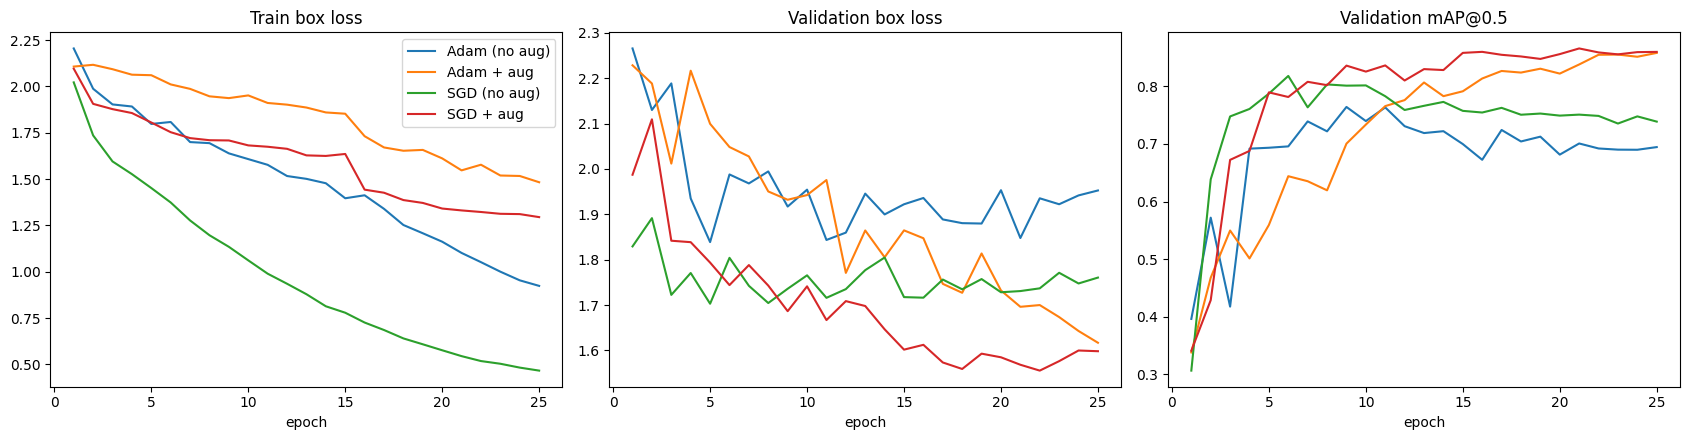

,epochs to val mAP50 >= 0.7,best epoch,best val mAP50,final-epoch val mAP50
condition,,,,
Adam (no aug),7,9,0.764,0.694
Adam + aug,9,25,0.858,0.858
SGD (no aug),3,6,0.818,0.739
SGD + aug,5,21,0.866,0.860


In [19]:
# Learning Curves and Convergence (Hypthoesis 2)
curves = {}
for c in CONDITIONS:
    d = pd.read_csv(RUNS[c] / "results.csv"); d.columns = [x.strip() for x in d.columns]; curves[c] = d
sample = curves[CONDITIONS[0]]
MAP50 = next(c for c in sample.columns if "mAP50(" in c)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for c, d in curves.items():
    axes[0].plot(d["epoch"], d["train/box_loss"], label=LABELS[c])
    axes[1].plot(d["epoch"], d["val/box_loss"], label=LABELS[c])
    axes[2].plot(d["epoch"], d[MAP50], label=LABELS[c])
for ax, t in zip(axes, ["Train box loss", "Validation box loss", "Validation mAP@0.5"]): ax.set_title(t); ax.set_xlabel("epoch")
axes[0].legend(); plt.tight_layout(); plt.savefig(RESULTS_DIR / "learning_curves.png", dpi=150); plt.show()

TARGET = 0.70
conv = pd.DataFrame([{
    "condition": LABELS[c],
    f"epochs to val mAP50 >= {TARGET}": (d.loc[d[MAP50] >= TARGET, "epoch"].min() if (d[MAP50] >= TARGET).any() else np.nan),
    "best epoch": int(d.loc[d[MAP50].idxmax(), "epoch"]), "best val mAP50": d[MAP50].max(), "final-epoch val mAP50": d[MAP50].iloc[-1],
} for c, d in curves.items()]).set_index("condition").round(3)
conv.to_csv(RESULTS_DIR / "convergence.csv"); display(conv)

In [21]:
#Hypothesis Checks
t = res[res.split == "test"].set_index(["optimizer", "augmented"])
print("H1: effect of augmentation on TEST performance")
for opt in ["adam", "sgd"]:
    for m in ["mAP50", "mAP50_95", "recall"]:
        d = t.loc[(opt, True), m] - t.loc[(opt, False), m]
        print(f"  {opt:4s} {m:9s}: aug - noaug = {d:+.3f}")
print("\nH2: Adam vs SGD")
for aug in [False, True]:
    a, s = t.loc[("adam", aug)], t.loc[("sgd", aug)]
    print(f"  augmented={aug}: test mAP50 Adam {a.mAP50:.3f} vs SGD {s.mAP50:.3f}; recall Adam {a.recall:.3f} vs SGD {s.recall:.3f}")
print("\nConvergence table above shows which optimizer reached the target mAP first.")
print("NOTE: one run per condition (seed 0). Differences of ~1-2 mAP points are within typical seed-to-seed noise.")

H1: effect of augmentation on TEST performance
  adam mAP50    : aug - noaug = +0.079
  adam mAP50_95 : aug - noaug = +0.096
  adam recall   : aug - noaug = +0.085
  sgd  mAP50    : aug - noaug = +0.053
  sgd  mAP50_95 : aug - noaug = +0.070
  sgd  recall   : aug - noaug = +0.045

H2: Adam vs SGD
  augmented=False: test mAP50 Adam 0.772 vs SGD 0.825; recall Adam 0.715 vs SGD 0.743
  augmented=True: test mAP50 Adam 0.850 vs SGD 0.878; recall Adam 0.800 vs SGD 0.788

Convergence table above shows which optimizer reached the target mAP first.
NOTE: one run per condition (seed 0). Differences of ~1-2 mAP points are within typical seed-to-seed noise.


In [22]:
#Breakdown by source system
# Source inferred from filename pattern; verify against the dataset docs and rename (e.g. SIRENA / CoastSnap / RipScout)
TS_RE = re.compile(r"^\d{4}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2}-.*?_\d+_(?:jpg|jpeg|png)$", re.I)
SOURCE_NAMES = {"timestamped": "timestamped", "other": "other"}      # edit once verified
def source_of(stem): return SOURCE_NAMES["timestamped" if TS_RE.match(stem.split(".rf.")[0]) else "other"]

test_df = pd.DataFrame([dict(image=clean_images[i], stem=clean_images[i].stem, positive=bool(targets[i]),
                             lines=[l.split() for l in (LABEL_DIR / f"{clean_images[i].stem}.txt").read_text().splitlines() if l.strip()],
                             source=source_of(clean_images[i].stem)) for i in test_i])
print(test_df.groupby(["source", "positive"]).size().unstack(fill_value=0))

BEST = res[res.split == "test"].sort_values("mAP50", ascending=False).iloc[0]
BEST_KEY = (BEST.optimizer, "aug" if BEST.augmented else "noaug"); print("Best condition:", BEST.condition)

src_rows = []
for src, g in test_df.groupby("source"):
    if g.positive.sum() == 0: continue
    root = Path(f"/content/test_by_source/{src}"); shutil.rmtree(root, ignore_errors=True)
    (root / "images" / "test").mkdir(parents=True); (root / "labels" / "test").mkdir(parents=True)
    for r in g.itertuples():
        shutil.copy2(r.image, root / "images" / "test" / r.image.name); shutil.copy2(LABEL_DIR / f"{r.stem}.txt", root / "labels" / "test" / f"{r.stem}.txt")
    (root / "data.yaml").write_text(f"path: {root}\ntrain: images/test\nval: images/test\ntest: images/test\n\nnames:\n  0: rip_current\n")
    r = evaluate(*BEST_KEY, data=root / "data.yaml", tag=f"_{src}"); r.update(source=src, n_images=len(g), n_positive=int(g.positive.sum())); src_rows.append(r)
src_df = pd.DataFrame(src_rows).set_index("source")[["n_images", "n_positive", "precision", "recall", "mAP50", "mAP50_95"]].round(3)
src_df.to_csv(RESULTS_DIR / "per_source_metrics.csv"); display(src_df)

positive     False  True 
source                   
other          159    426
timestamped      4      3
Best condition: SGD + aug
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-obb summary (fused): 129 layers, 2,446,602 parameters, 0 gradients, 5.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2074.1±1006.1 MB/s, size: 1360.8 KB)
val: Scanning /content/test_by_source/other/labels/test... 585 images, 159 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 585/585 485.5it/s 1.2s
val: New cache created: /content/test_by_source/other/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 2.2it/s 16.9s
                   all        585        500      0.867      0.793      0.881      0.524
Speed: 1.7ms preprocess, 5.6ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/eval/sgd_aug_test_other
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+c

,n_images,n_positive,precision,recall,mAP50,mAP50_95
source,,,,,,
other,585,426,0.867,0.793,0.881,0.524
timestamped,7,3,0.339,0.400,0.308,0.123


## 6. Error analysis (failure cases)
We run the best model (**SGD + augmentation**) on every test image at confidence ≥ 0.25 and match predicted to labeled boxes at oriented IoU > 0.5. Unmatched predictions are **false positives**; unmatched labels are **false negatives** (missed rips). Results are grouped by image brightness and by rip size.

In [23]:
import cv2
from ultralytics.utils.metrics import batch_probiou
CONF = 0.25

def poly_to_xywhr(line, W, H):
    pts = (np.array(list(map(float, line[1:9]))).reshape(4, 2) * [W, H]).astype(np.float32)
    (cx, cy), (w, h), ang = cv2.minAreaRect(pts)
    return [cx, cy, w, h, np.deg2rad(ang)]

model = YOLO(str(RUNS[BEST_KEY] / "weights" / "best.pt"))
recs, cache = [], {}
for r in test_df.itertuples():
    res_ = model.predict(str(OUTPUT_DIR / "images" / "test" / r.image.name), conf=CONF, imgsz=640, device=DEVICE, verbose=False)[0]
    H, W = res_.orig_shape
    gt = torch.tensor([poly_to_xywhr(l, W, H) for l in r.lines], dtype=torch.float32).reshape(-1, 5)
    pr = res_.obb.xywhr.cpu() if res_.obb is not None and len(res_.obb) else torch.zeros((0, 5))
    tp = 0
    if len(gt) and len(pr):
        iou = batch_probiou(gt, pr).numpy(); used = set()
        for gi in range(len(gt)):
            cand = [(iou[gi, pj], pj) for pj in range(len(pr)) if pj not in used and iou[gi, pj] > 0.5]
            if cand: used.add(max(cand)[1]); tp += 1
    gray = np.asarray(Image.open(r.image).convert("L"), dtype=np.float32)
    area = float(np.mean([(g[2] * g[3]) / (W * H) for g in gt.numpy()])) if len(gt) else np.nan
    recs.append(dict(image=r.image.name, source=r.source, n_gt=len(gt), tp=tp, fp=len(pr) - tp, fn=len(gt) - tp, brightness=gray.mean(), rip_area_frac=area))
    cache[r.image.name] = (res_, r.lines)

err = pd.DataFrame(recs); err.to_csv(RESULTS_DIR / "error_analysis.csv", index=False)
tot = err[["tp", "fp", "fn"]].sum()
print(f"conf>={CONF}, IoU>0.5: TP={tot.tp} FP={tot.fp} FN={tot.fn} | precision={tot.tp/(tot.tp+tot.fp):.3f} recall={tot.tp/(tot.tp+tot.fn):.3f}")
err["lighting"] = pd.qcut(err.brightness, 3, labels=["dark", "medium", "bright"])
err["rip size"] = pd.qcut(err.rip_area_frac, 3, labels=["small", "medium", "large"], duplicates="drop")
for k in ["source", "lighting", "rip size"]:
    print(f"\nBy {k}:"); display(err.groupby(k, observed=True)[["tp", "fp", "fn"]].sum())

conf>=0.25, IoU>0.5: TP=411 FP=99 FN=94 | precision=0.806 recall=0.814

By source:


,tp,fp,fn
source,,,
other,410,95,90
timestamped,1,4,4



By lighting:


,tp,fp,fn
lighting,,,
dark,112,40,42
medium,118,40,38
bright,181,19,14



By rip size:


,tp,fp,fn
rip size,,,
small,130,39,57
medium,143,17,32
large,138,5,5


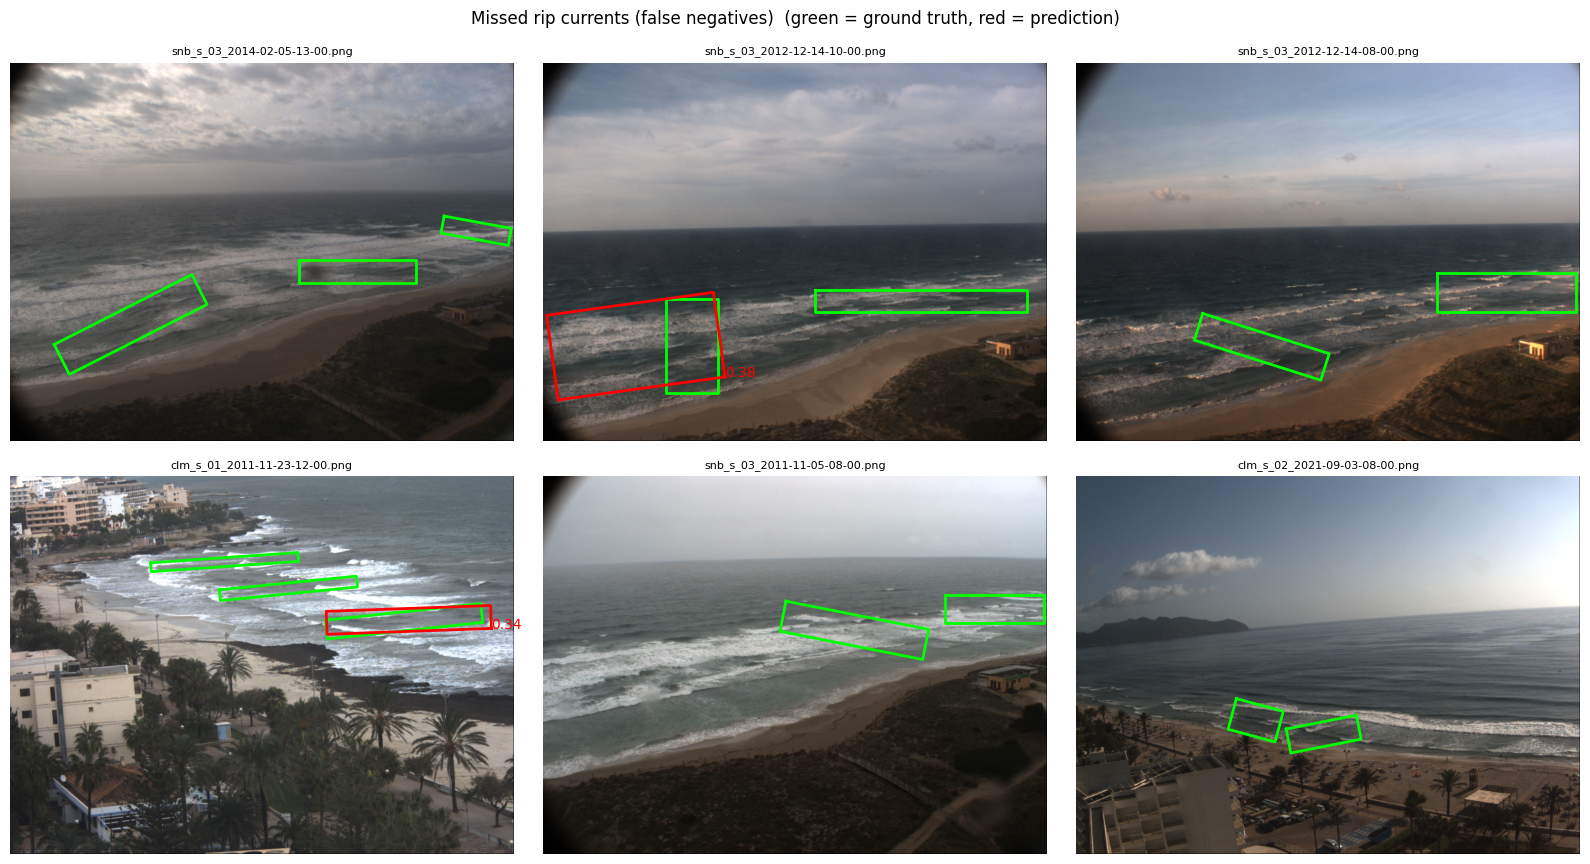

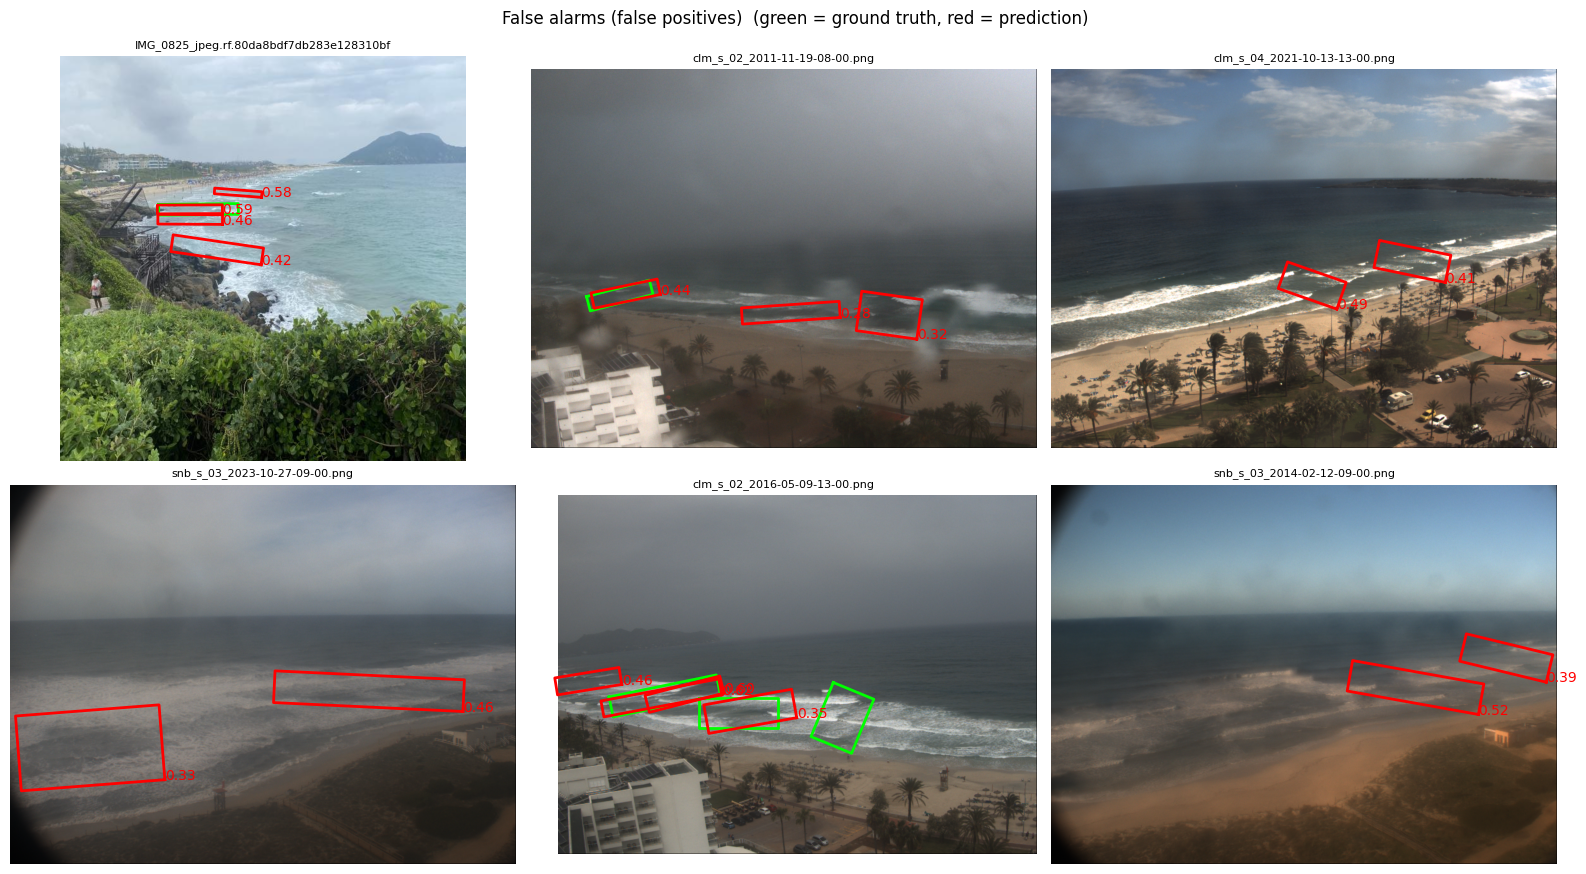

In [24]:
def draw_gt(ax, path, lines):
    im = Image.open(path).convert("RGB"); W, H = im.size; ax.imshow(im); ax.axis("off")
    for l in lines:
        pts = np.array(list(map(float, l[1:9]))).reshape(4, 2) * [W, H]; ax.plot(*np.vstack([pts, pts[0]]).T, color="lime", linewidth=2)

def gallery(names, title, n=6):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9)); fig.suptitle(title + "  (green = ground truth, red = prediction)")
    for ax in axes.ravel(): ax.axis("off")
    for ax, name in zip(axes.ravel(), list(names)[:n]):
        r_, lines = cache[name]; draw_gt(ax, OUTPUT_DIR / "images" / "test" / name, lines)
        if r_.obb is not None and len(r_.obb):
            for poly, c in zip(r_.obb.xyxyxyxy.cpu().numpy(), r_.obb.conf.cpu().numpy()):
                ax.plot(*np.vstack([poly, poly[0]]).T, color="red", linewidth=2); ax.text(*poly[0], f"{c:.2f}", color="red")
        ax.set_title(name[:40], fontsize=8)
    plt.tight_layout(); plt.savefig(RESULTS_DIR / f"{title.split()[0].lower()}_gallery.png", dpi=120); plt.show()

gallery(err[err.fn > 0].sort_values("fn", ascending=False).image, "Missed rip currents (false negatives)")
gallery(err[err.fp > 0].sort_values("fp", ascending=False).image, "False alarms (false positives)")